# PCA Sensitivity Analysis - Pathology Classification

## Objective
Evaluate the trade-off: does PCA transformation that mitigates site effects hurt pathology classification?

## Experiment Design
- **Methods tested:** raw, sitewise, combat, neurocombat, covbat
- **PCA variants:** none, all (full), 0.99, 0.95, 0.90, 0.80
- **Metric:** Pathology classification AUC (higher = better)

## Key Results

| Method | No PCA | PCA 0.80 |
|--------|--------|----------|
| raw | 0.803 | 0.772 |
| combat | **0.811** | 0.782 |
| sitewise | 0.806 | 0.782 |

## Trade-off Analysis
- **Site MCC reduction:** 0.957 → 0.564 (ComBat with PCA 0.80)
- **Pathology AUC cost:** 0.811 → 0.782 (~3% drop)

The trade-off exists but may be acceptable depending on the use case. PCA helps site-invariance at a modest pathology cost.

## Conclusion
PCA transformation offers a partial solution to the paradox, but a better approach (like DANN) could potentially achieve site-invariance without sacrificing pathology performance.

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH_CATBOOST = 'results/tables/05_pca_sensitivity/pca_sensitivity_results_patho_catboost.csv'
FIGURES_DIR  = 'results/figures/05_pca_sensitivity/pathology_classification'

METHODS      = ['raw', 'sitewise', 'combat', 'neurocombat', 'covbat']
PCA_VARIANTS = ['none', 'all', '0.99', '0.95', '0.9', '0.8']

COLOR_GRID = ['black', 'tomato', 'skyblue', 'green', 'orange', 'purple', 'brown', 'cyan']

In [5]:
catboost_df = pd.read_csv(RESULTS_PATH_CATBOOST)
print(catboost_df.shape)
print('methods:', catboost_df['method'].unique())
print('pca_var:', catboost_df['pca_var'].unique())

(900, 12)
methods: ['raw' 'sitewise' 'combat' 'neurocombat' 'covbat']
pca_var: ['none' 'all' '0.99' '0.95' '0.9' '0.8']


## Pathology AUC per hospital — grouped by method

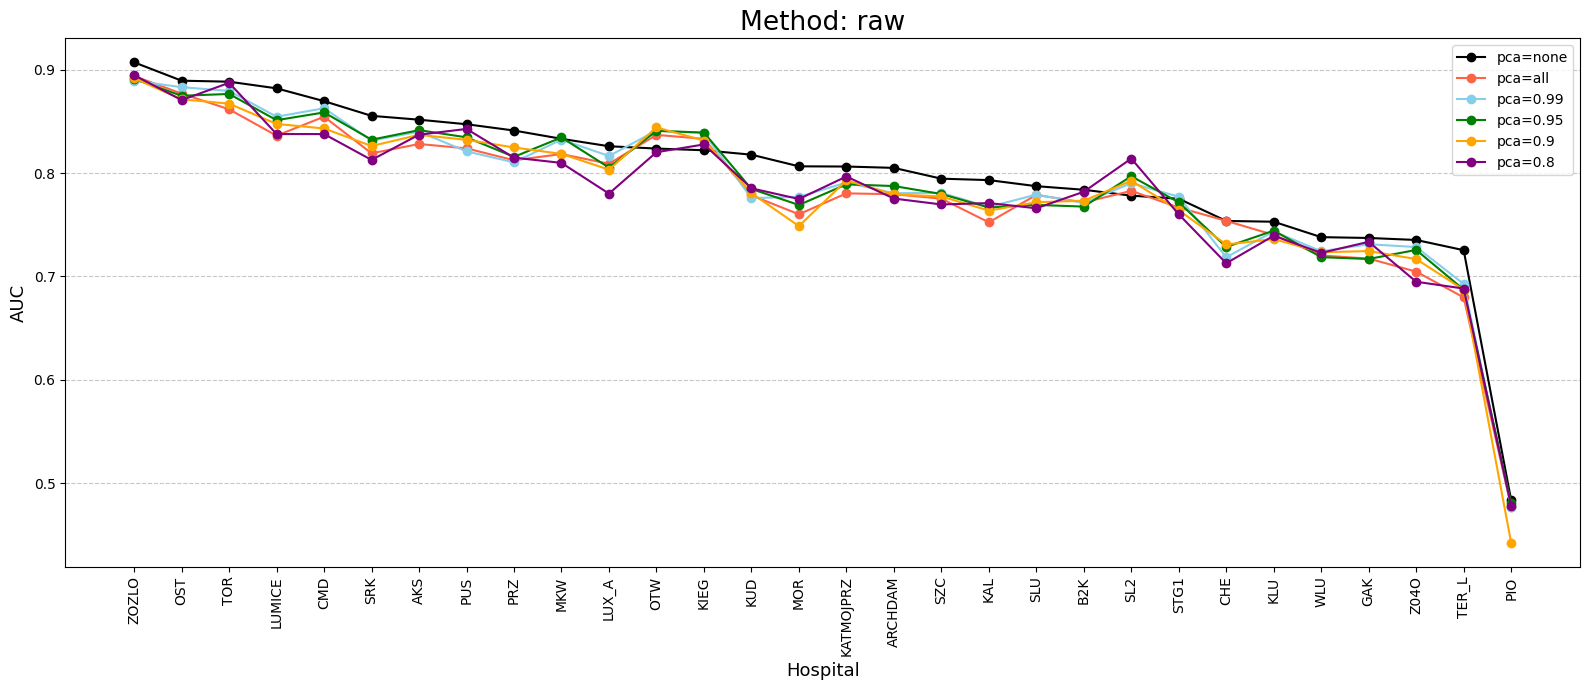

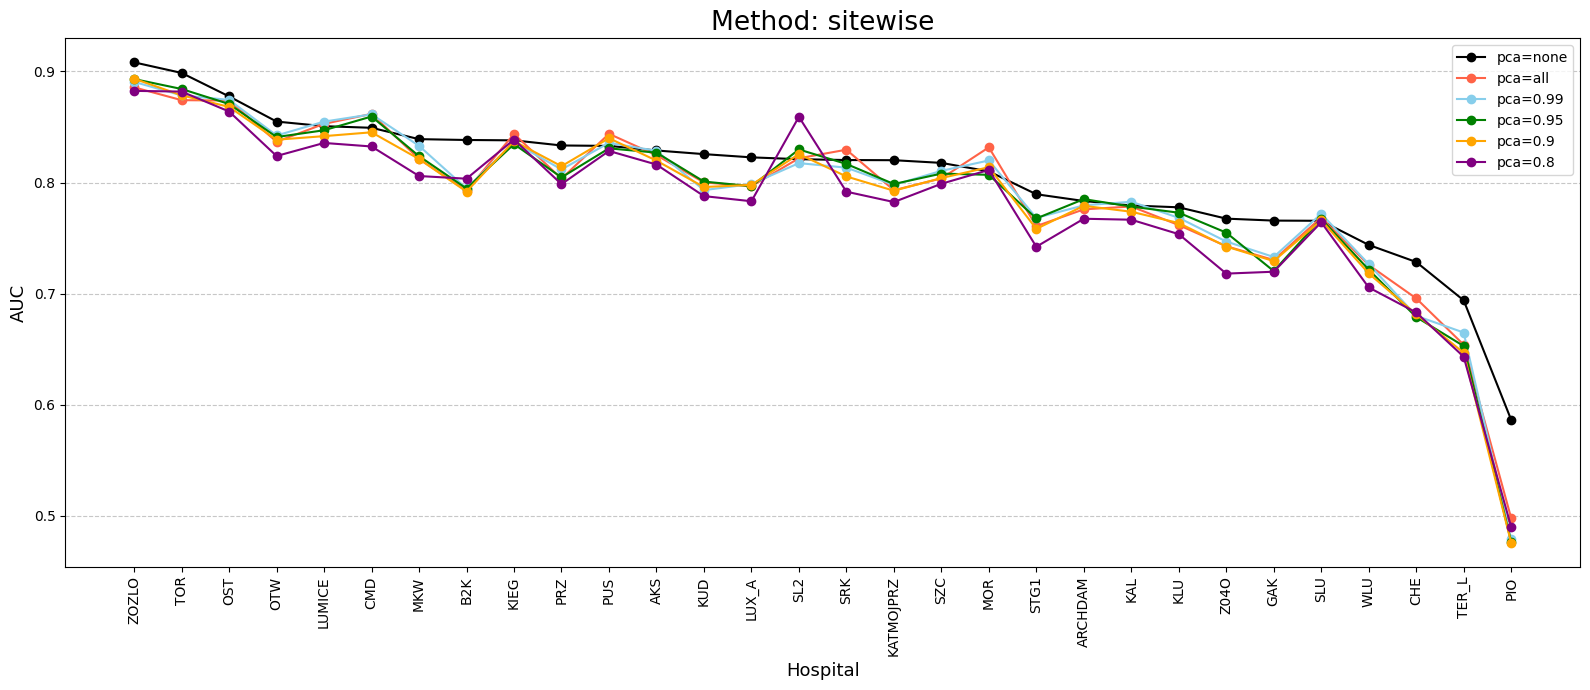

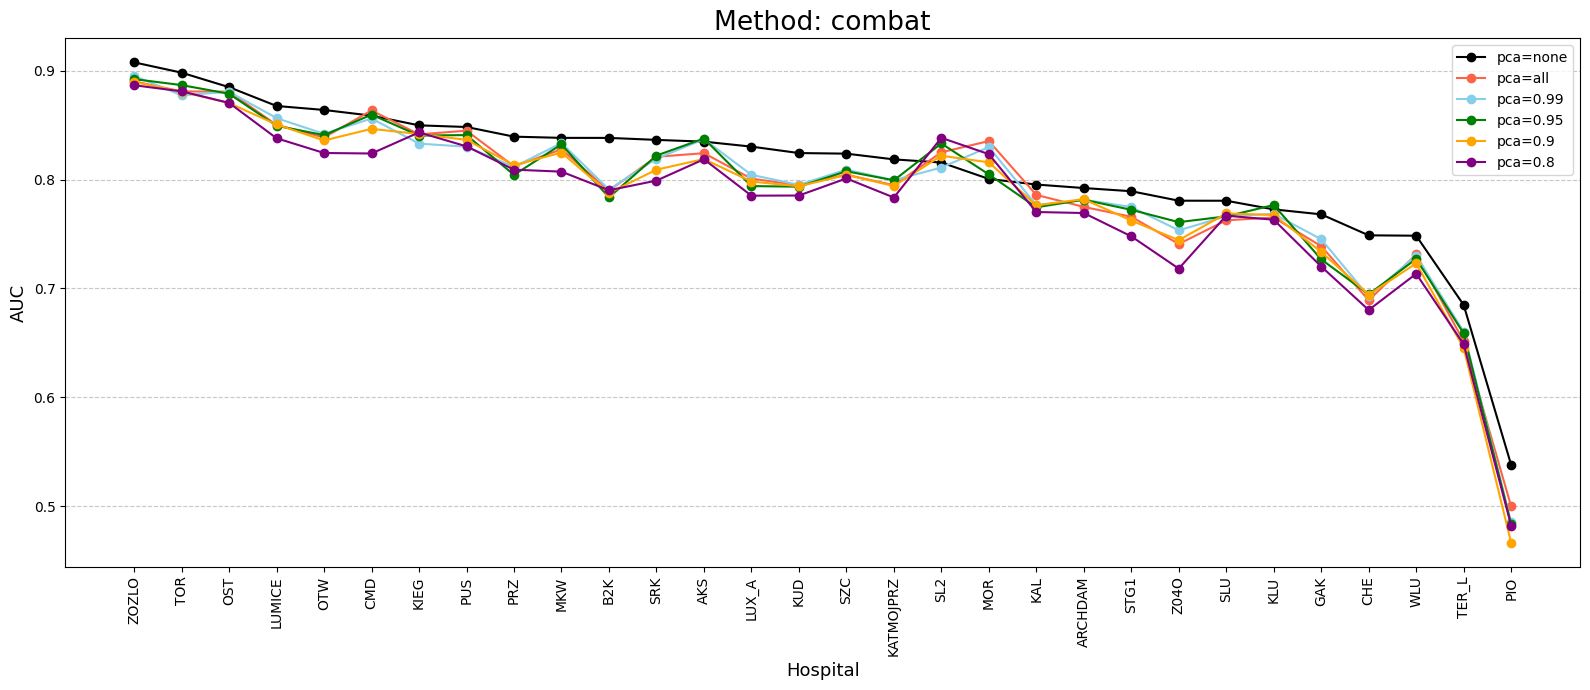

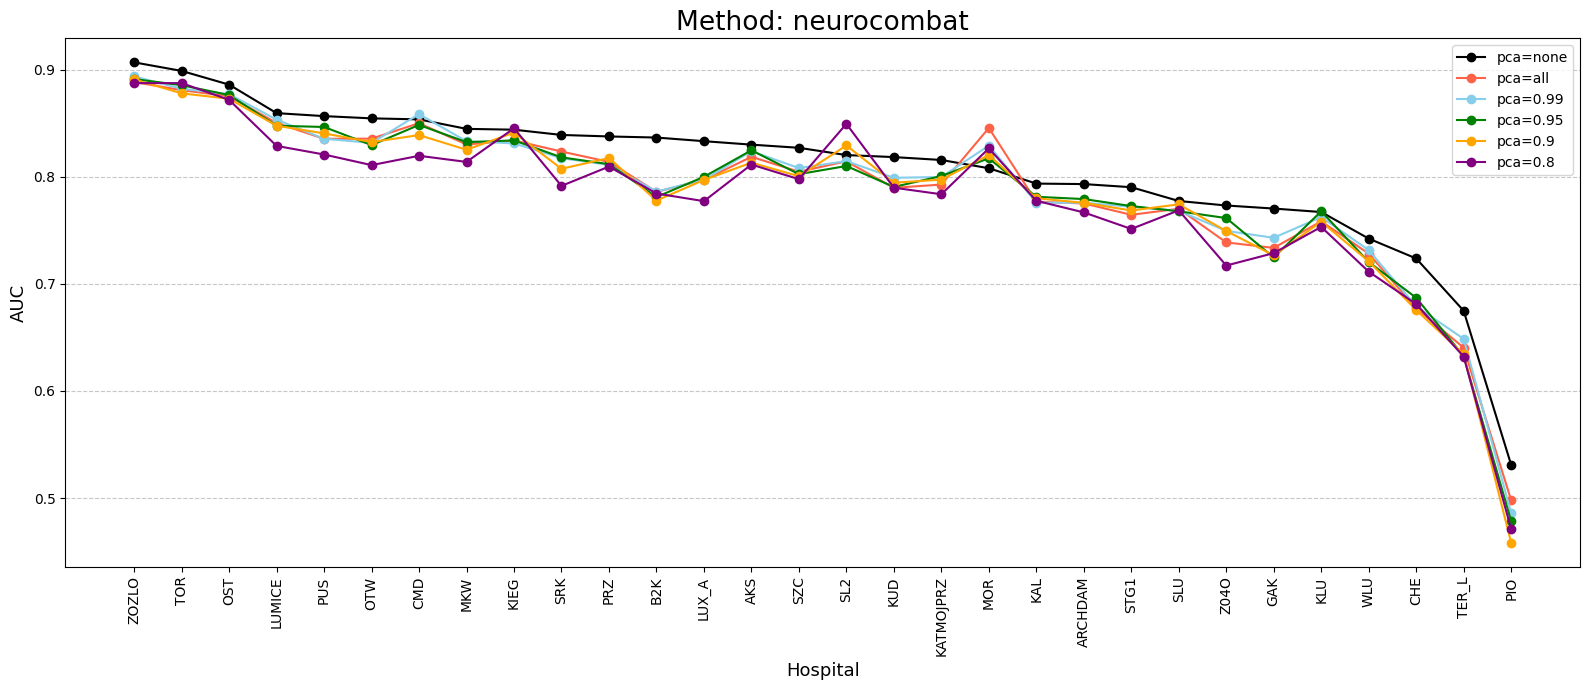

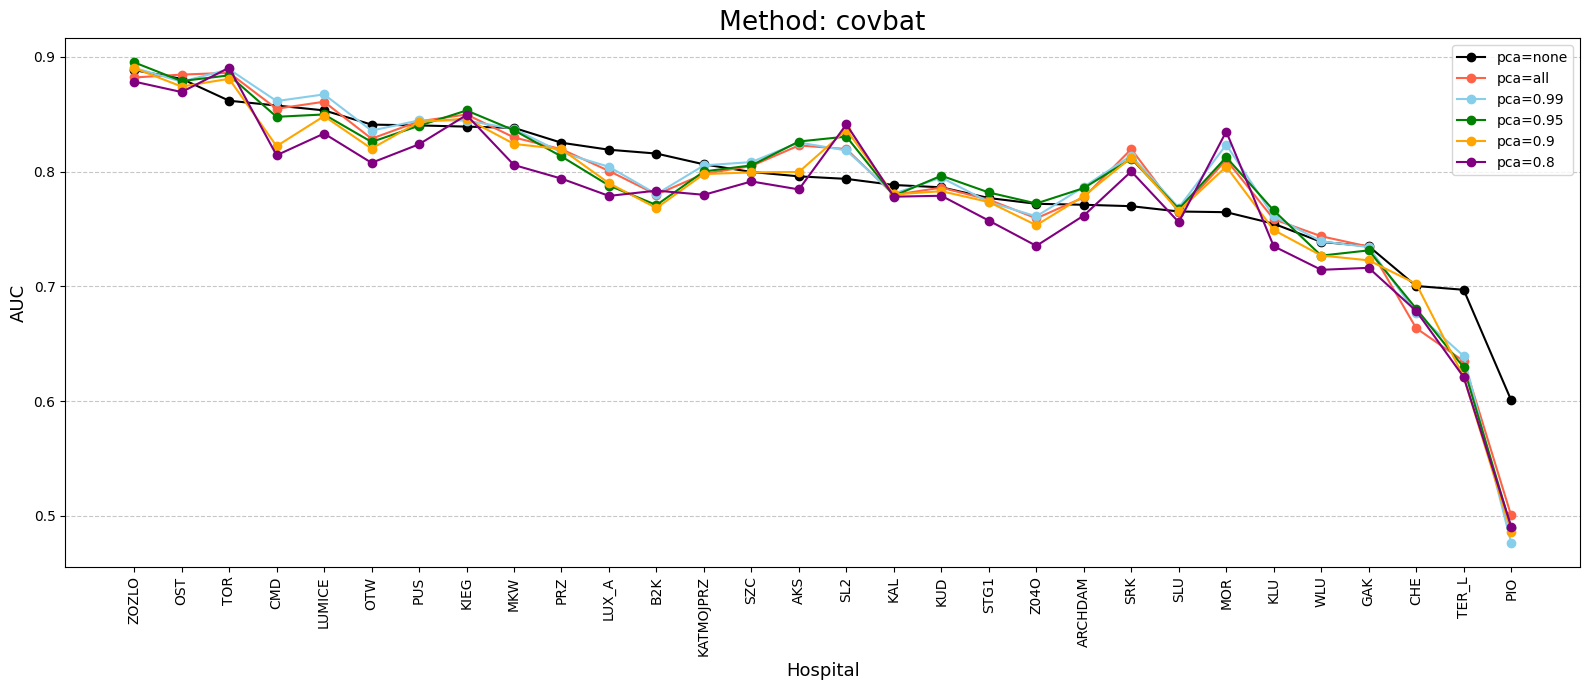

In [6]:
os.makedirs(FIGURES_DIR, exist_ok=True)

metric = 'auc'
for method in METHODS:
pivot = catboost_df[catboost_df['method'] == method].pivot_table(
    index='pca_var', columns='hospital', values=metric
)
hospitals_sorted = pivot.loc['none'].sort_values(ascending=False).index.values

fig, ax = plt.subplots(figsize=(16, 7))
for i, pca in enumerate(PCA_VARIANTS):
    values = [pivot.loc[pca].get(h, float('nan')) for h in hospitals_sorted]
    ax.plot(hospitals_sorted, values, marker='o', linestyle='-',
            color=COLOR_GRID[i], label=f"pca={pca}")

ax.set_title(f"Method: {method}", fontsize=19)
ax.set_ylabel(metric.upper(), fontsize=13)
ax.set_xlabel("Hospital", fontsize=13)
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()
fig.tight_layout()
#fig.savefig(f"{FIGURES_DIR}/patho_auc_method_{method}.png", dpi=150, bbox_inches='tight')
plt.show()

## Pathology AUC per hospital — grouped by PCA variant

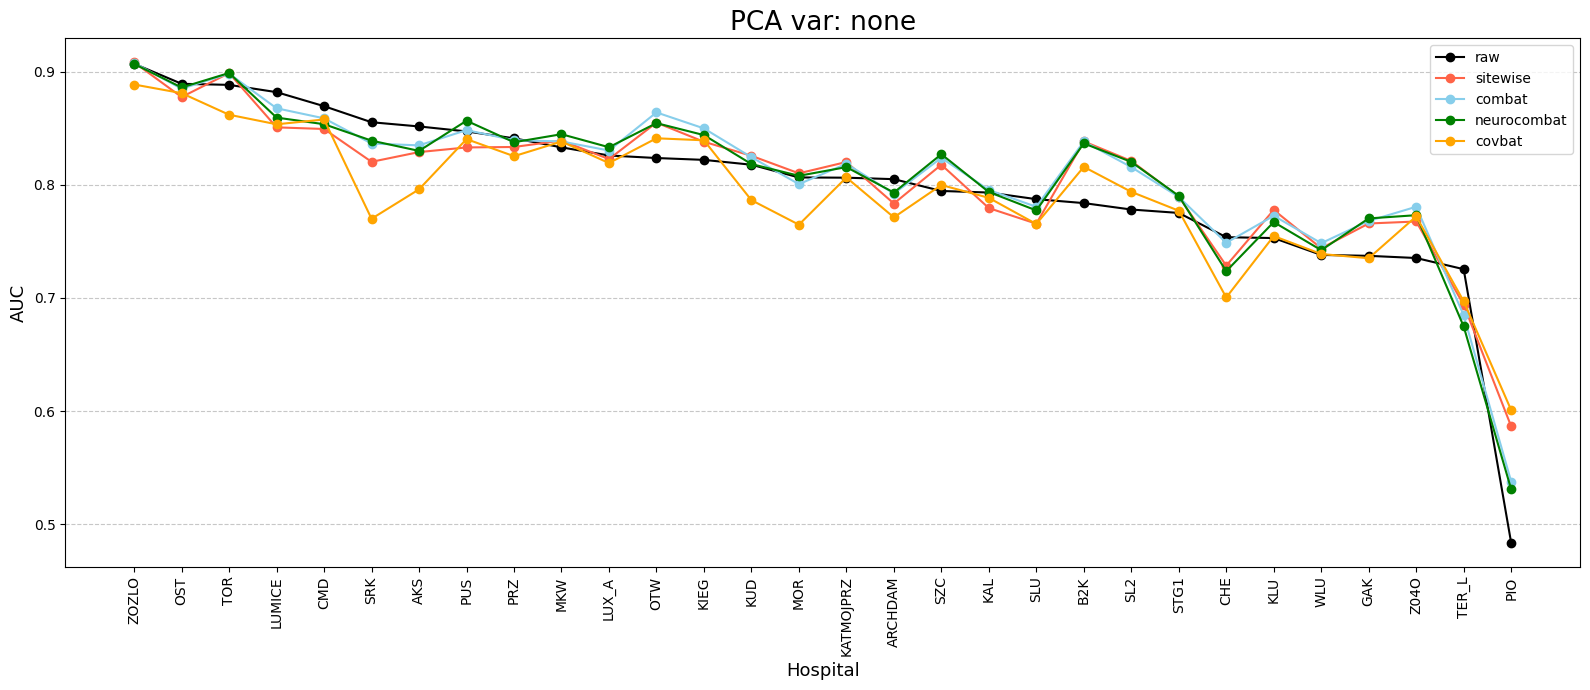

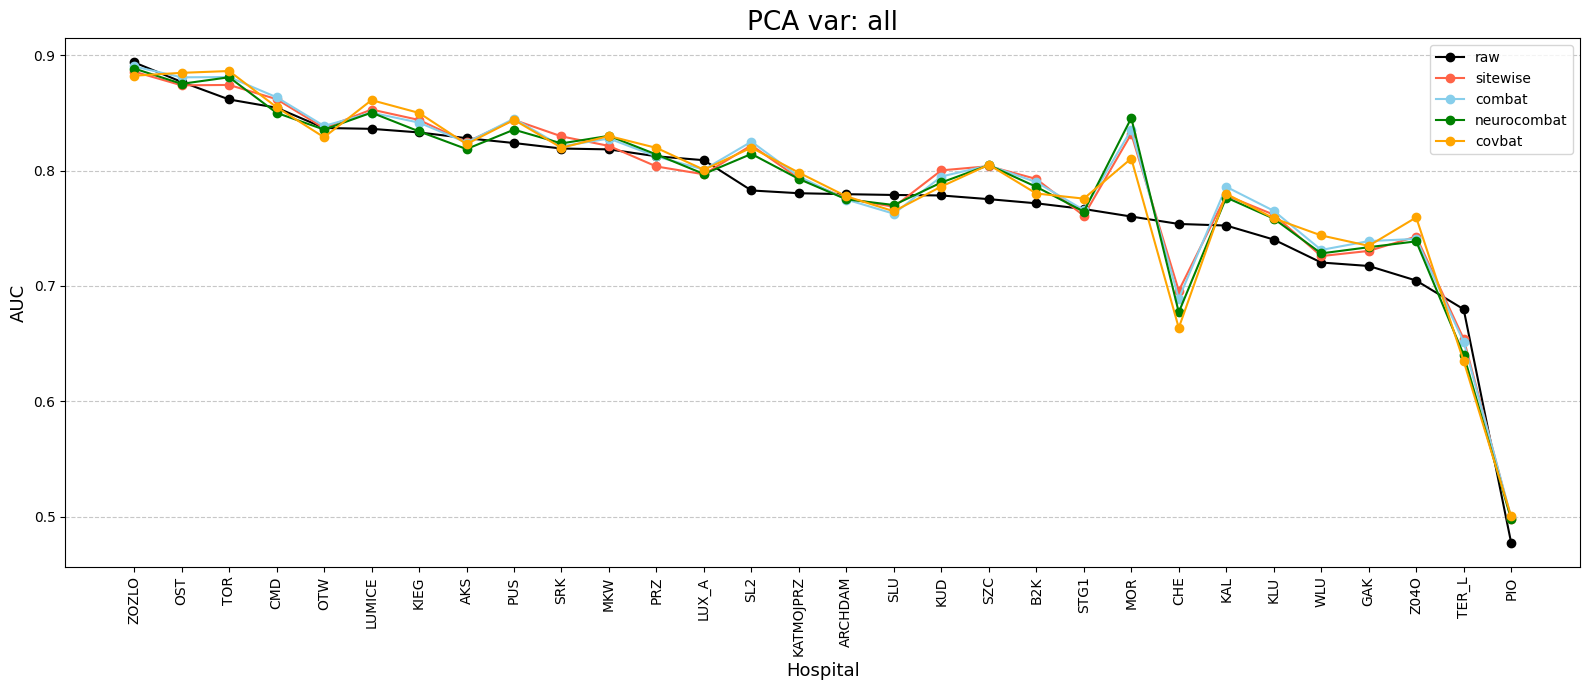

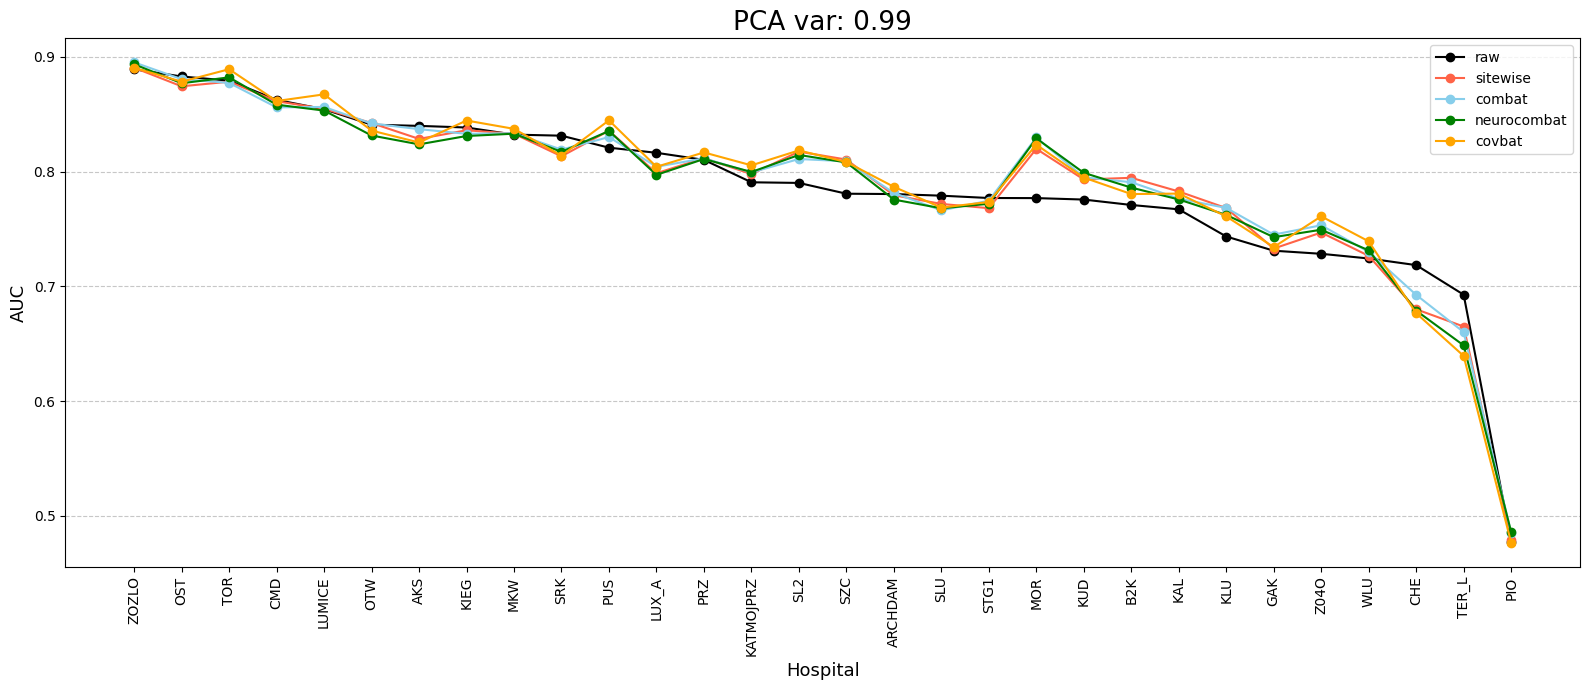

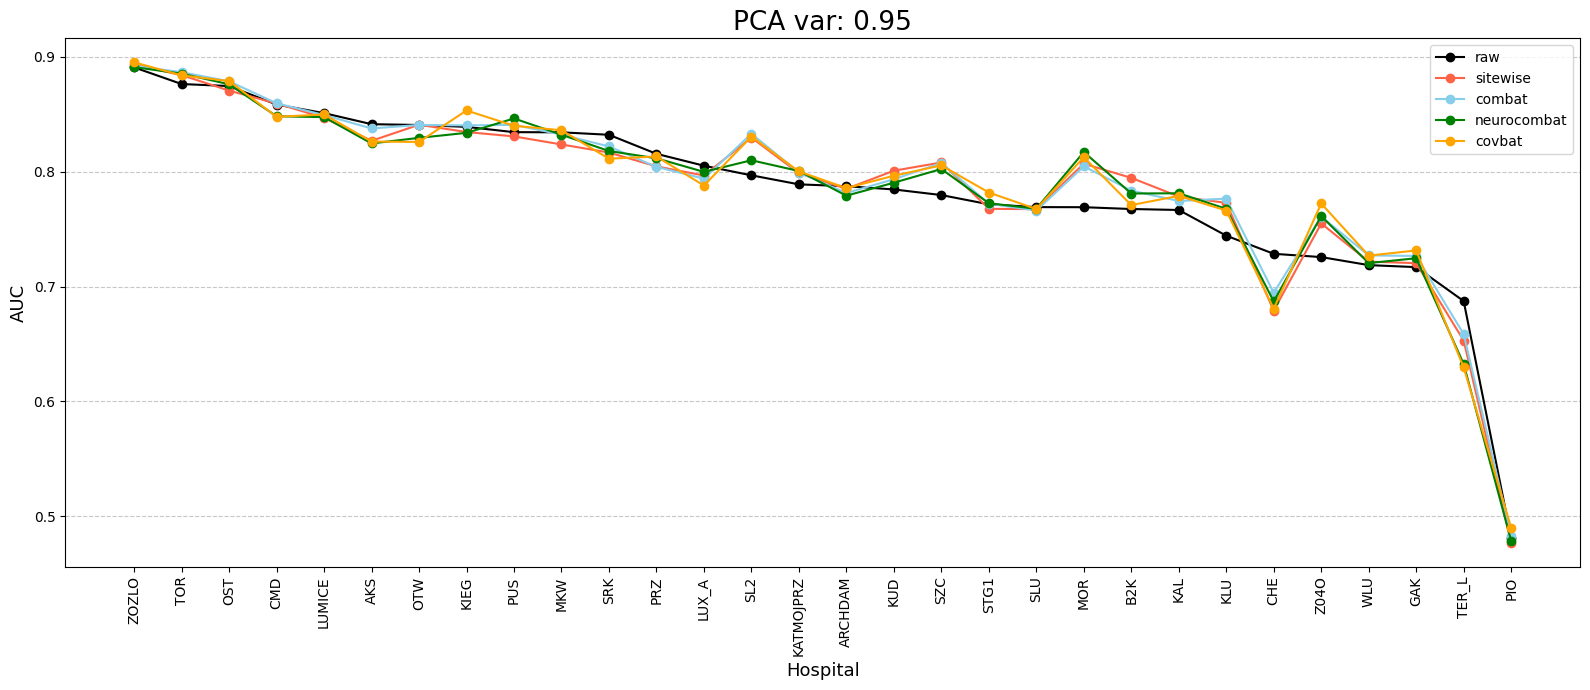

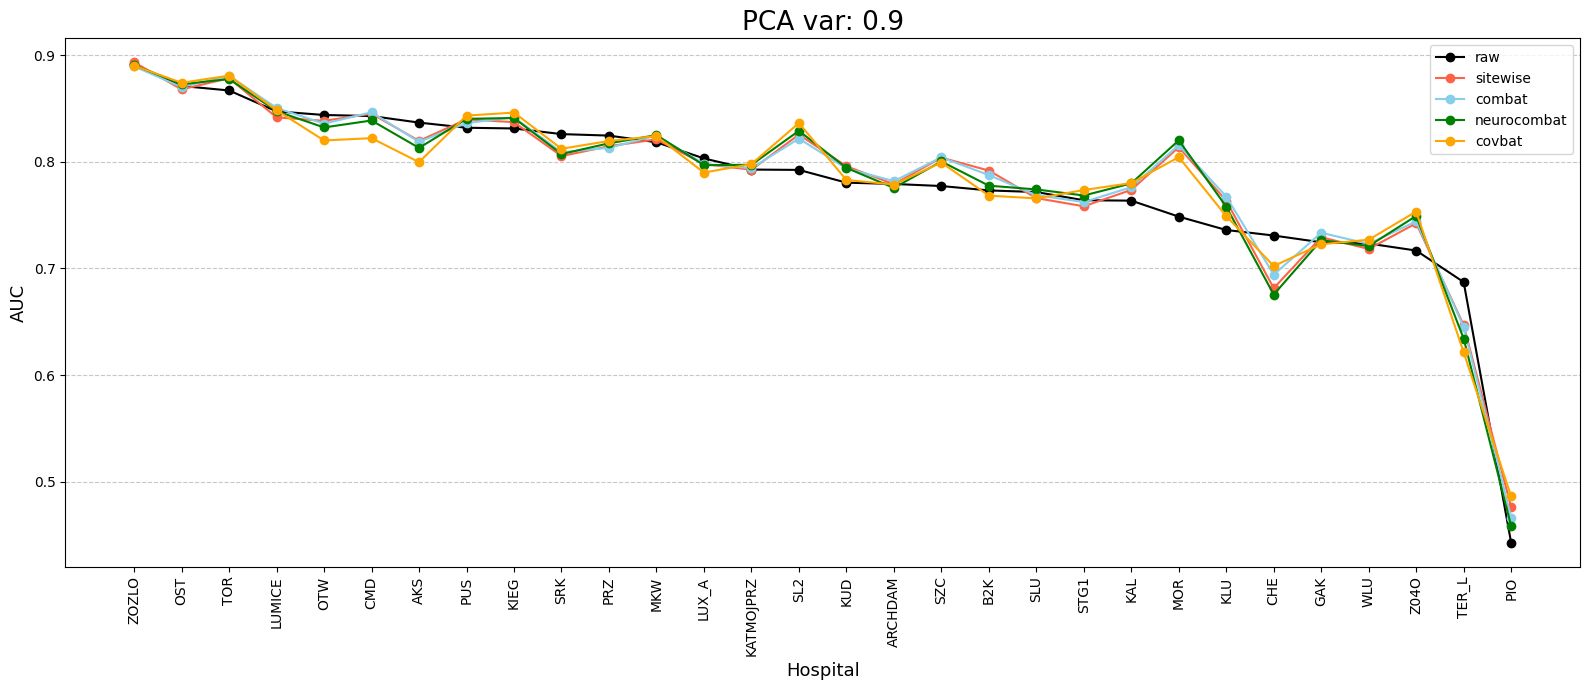

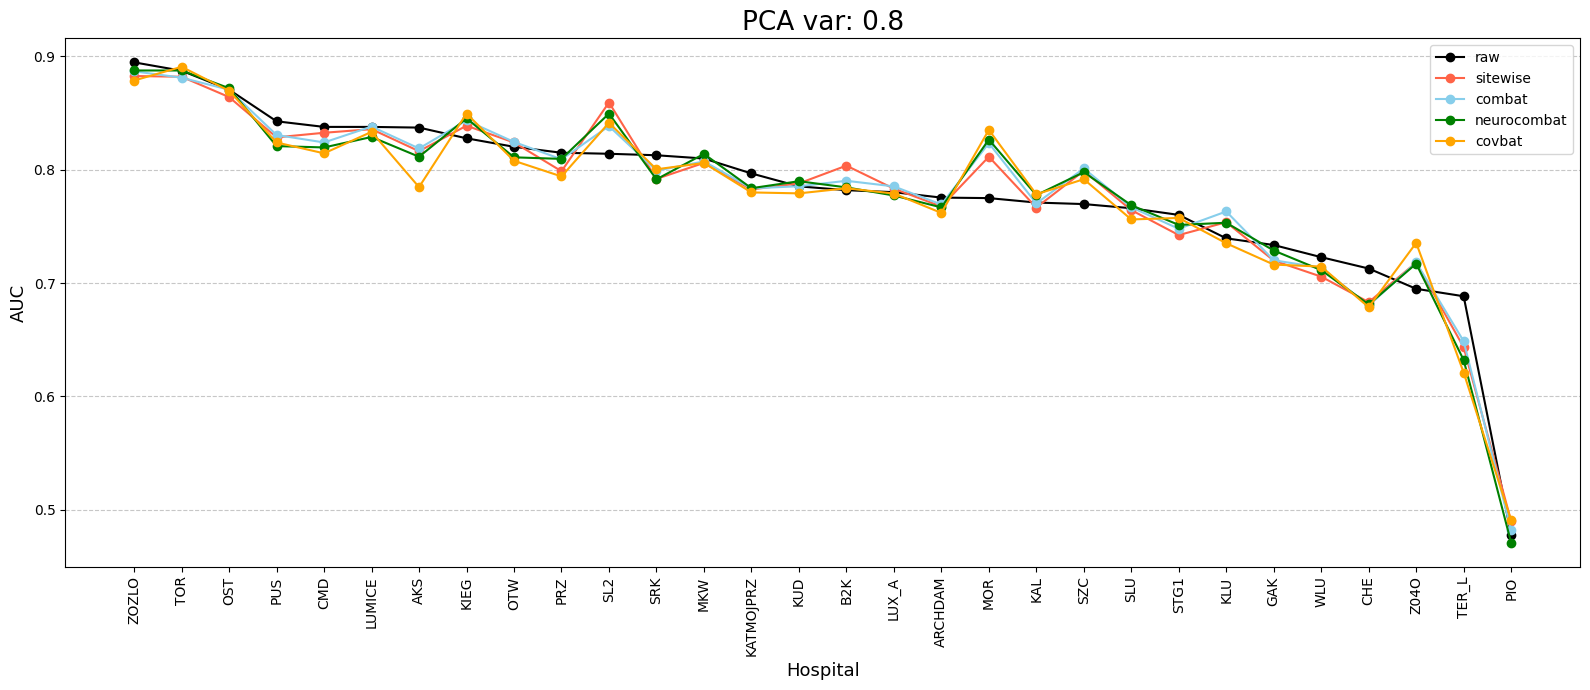

In [7]:
metric = 'auc'
for pca in PCA_VARIANTS:
    pivot = catboost_df[catboost_df['pca_var'] == pca].pivot_table(
        index='method', columns='hospital', values=metric
    )
    hospitals_sorted = pivot.loc['raw'].sort_values(ascending=False).index.values

    fig, ax = plt.subplots(figsize=(16, 7))
    for i, method in enumerate(METHODS):
        values = [pivot.loc[method].get(h, float('nan')) for h in hospitals_sorted]
        ax.plot(hospitals_sorted, values, marker='o', linestyle='-',
                color=COLOR_GRID[i], label=method)

    ax.set_title(f"PCA var: {pca}", fontsize=19)
    ax.set_ylabel(metric.upper(), fontsize=13)
    ax.set_xlabel("Hospital", fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    fig.tight_layout()
    #fig.savefig(f"{FIGURES_DIR}/patho_auc_pca_{pca.replace('.', '')}.png", dpi=150, bbox_inches='tight')
    plt.show()

# Logistic Regression Analysis

In [50]:
RESULTS_PATH_LOGREG = 'results/tables/05_pca_sensitivity/pca_sensitivity_results_patho_logreg.csv'
MODELS       = ['catboost', 'logreg']
METHODS      = ['raw', 'combat',]
PCA_VARIANTS = ['none', 'all', '0.99', '0.95', '0.9', '0.8']

logreg_df = pd.read_csv(RESULTS_PATH_LOGREG)
print(logreg_df.shape)
print('methods:', logreg_df['method'].unique())
print('pca_var:', logreg_df['pca_var'].unique())

(360, 13)
methods: ['raw' 'combat']
pca_var: ['none' 'all' '0.99' '0.95' '0.9' '0.8']


In [41]:

metric = 'auc'

baseline = logreg_df[(logreg_df['method'] == 'raw') & (logreg_df['pca_var'] == 'none')]
hospitals_sorted = baseline.groupby('hospital')[metric].mean().sort_values(ascending=False).index.values


## 1. Harmonization Effect

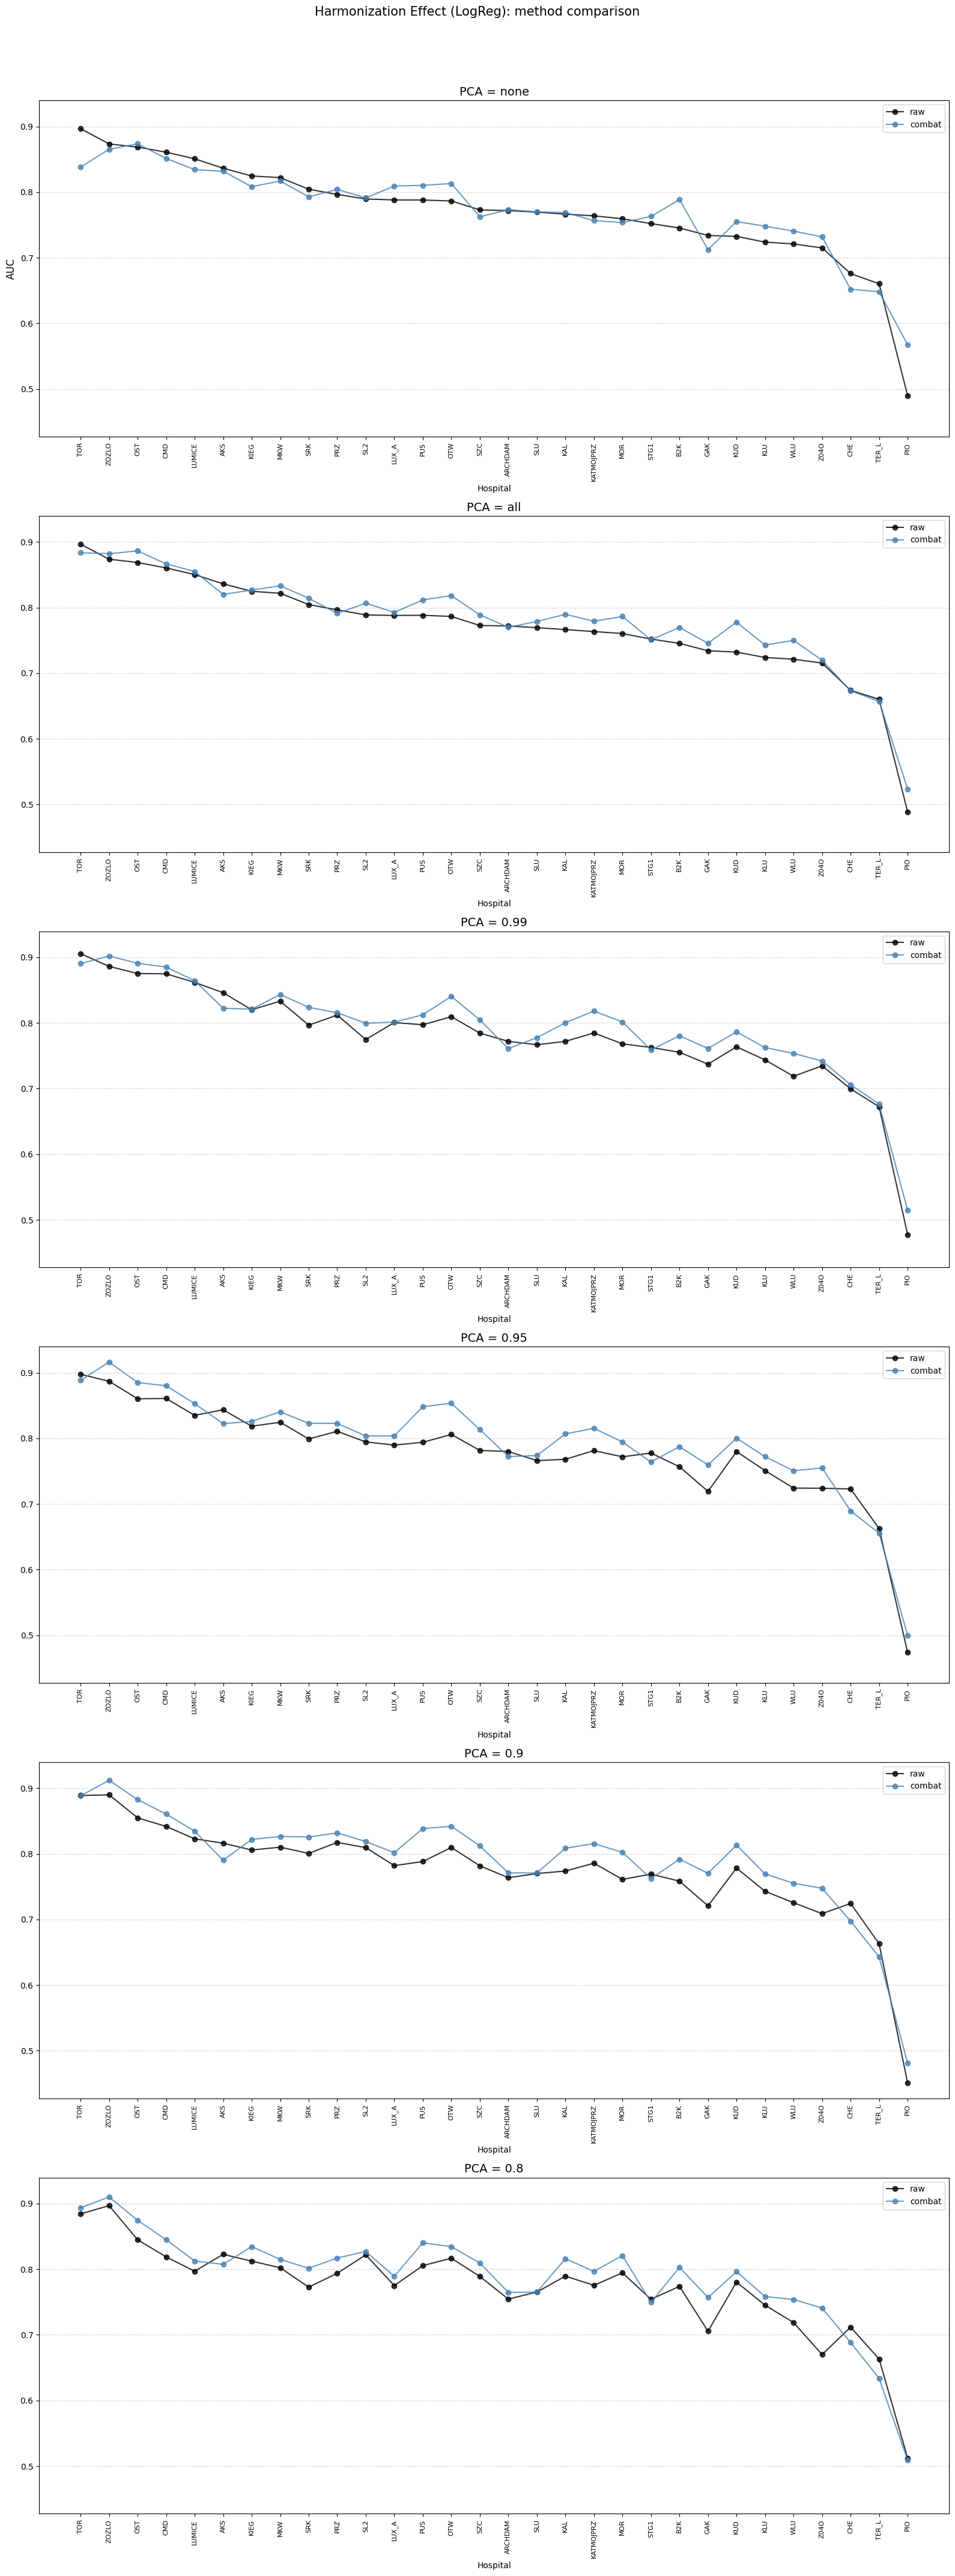

In [48]:
fig, axes = plt.subplots(len(PCA_VARIANTS), 1, figsize=(16, 7 * len(PCA_VARIANTS)), sharey=True)
METHOD_COLORS = {'raw': 'black', 'combat': 'steelblue'}

for ax, pca in zip(axes, PCA_VARIANTS):
  for method in METHODS:
      sub = logreg_df[(logreg_df['method'] == method) & (logreg_df['pca_var'] == pca)]
      vals = sub.set_index('hospital').reindex(hospitals_sorted)[metric]
      ax.plot(range(len(hospitals_sorted)), vals.values, marker='o',
              color=METHOD_COLORS[method], label=method, alpha=0.8)

  ax.set_title(f'PCA = {pca}', fontsize=14)
  ax.set_xticks(range(len(hospitals_sorted)))
  ax.set_xticklabels(hospitals_sorted, rotation=90, fontsize=8)
  ax.set_xlabel('Hospital')
  ax.grid(axis='y', linestyle='--', alpha=0.5)
  ax.legend()

axes[0].set_ylabel(metric.upper(), fontsize=12)
fig.suptitle('Harmonization Effect (LogReg): method comparison', fontsize=15, y=1.02)
fig.tight_layout()
plt.show()


## 2. PCA Effect (none vs all), faceted by method

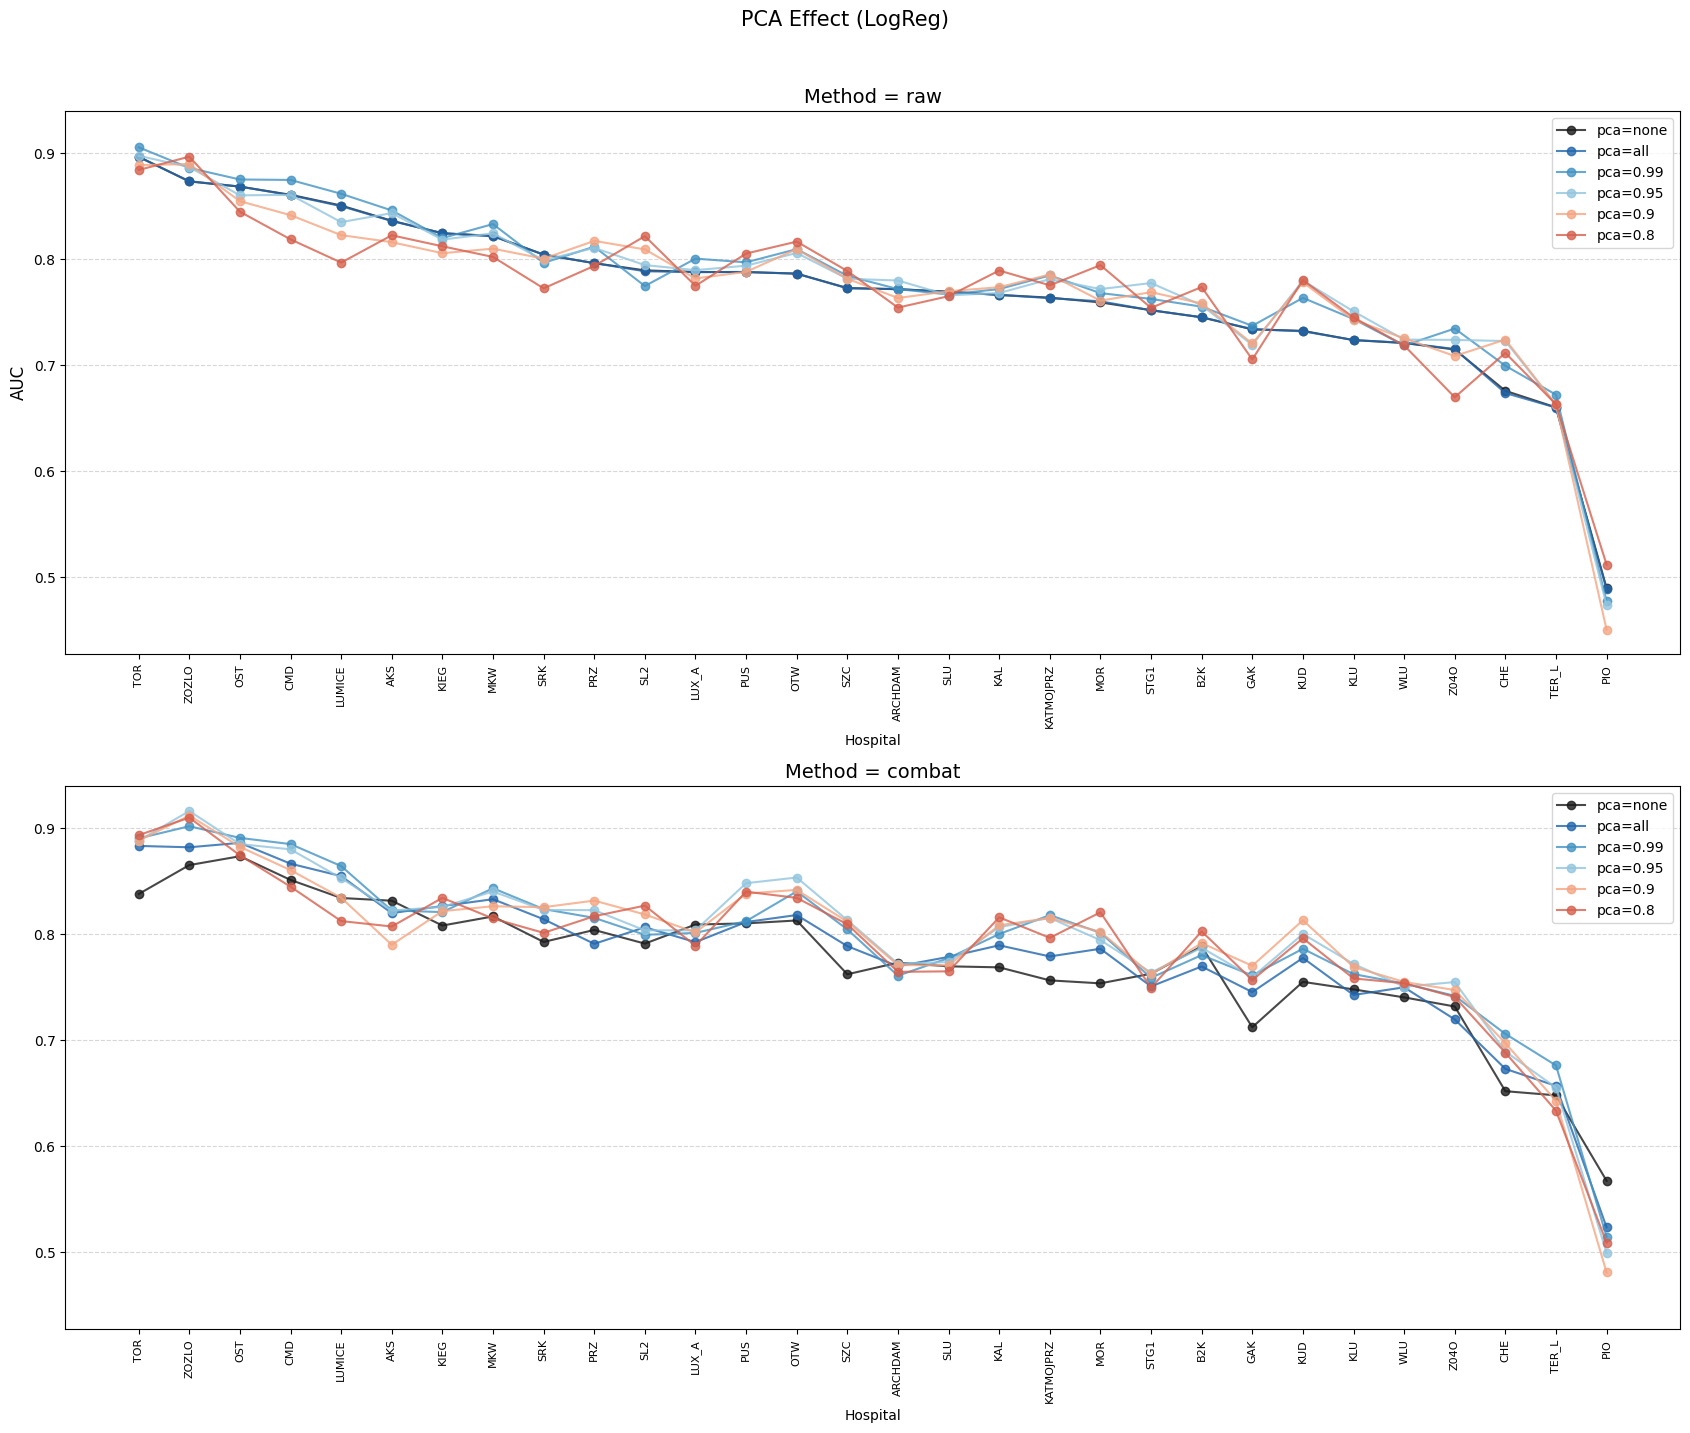

In [62]:
fig, axes = plt.subplots(len(METHODS), 1, figsize=(17, 7 * len(METHODS)), sharey=True)
PCA_COLORS = {
  'none': '#1a1a1a',
  'all':  '#2166ac',
  '0.99': '#4393c3',
  '0.95': '#92c5de',
  '0.9':  '#f4a582',
  '0.8':  '#d6604d',
}
for ax, method in zip(axes, METHODS):
  for pca in PCA_VARIANTS:
      sub = logreg_df[(logreg_df['method'] == method) & (logreg_df['pca_var'] == pca)]
      vals = sub.set_index('hospital').reindex(hospitals_sorted)[metric]
      ax.plot(range(len(hospitals_sorted)), vals.values, marker='o',
              color=PCA_COLORS[pca], label=f'pca={pca}', alpha=0.8)

  ax.set_title(f'Method = {method}', fontsize=14)
  ax.set_xticks(range(len(hospitals_sorted)))
  ax.set_xticklabels(hospitals_sorted, rotation=90, fontsize=8)
  ax.set_xlabel('Hospital')
  ax.grid(axis='y', linestyle='--', alpha=0.5)
  ax.legend()

axes[0].set_ylabel(metric.upper(), fontsize=12)
fig.suptitle('PCA Effect (LogReg)', fontsize=15, y=1.02)
fig.tight_layout()
plt.show()


## Multi-Model Comparison: Logistic Regression vs CatBoost

In [63]:
multimodel_df = pd.concat([
logreg_df,
catboost_df.assign(model='catboost').merge(
  logreg_df[['method', 'pca_var']].drop_duplicates(),
  on=['method', 'pca_var']
)
], ignore_index=True)

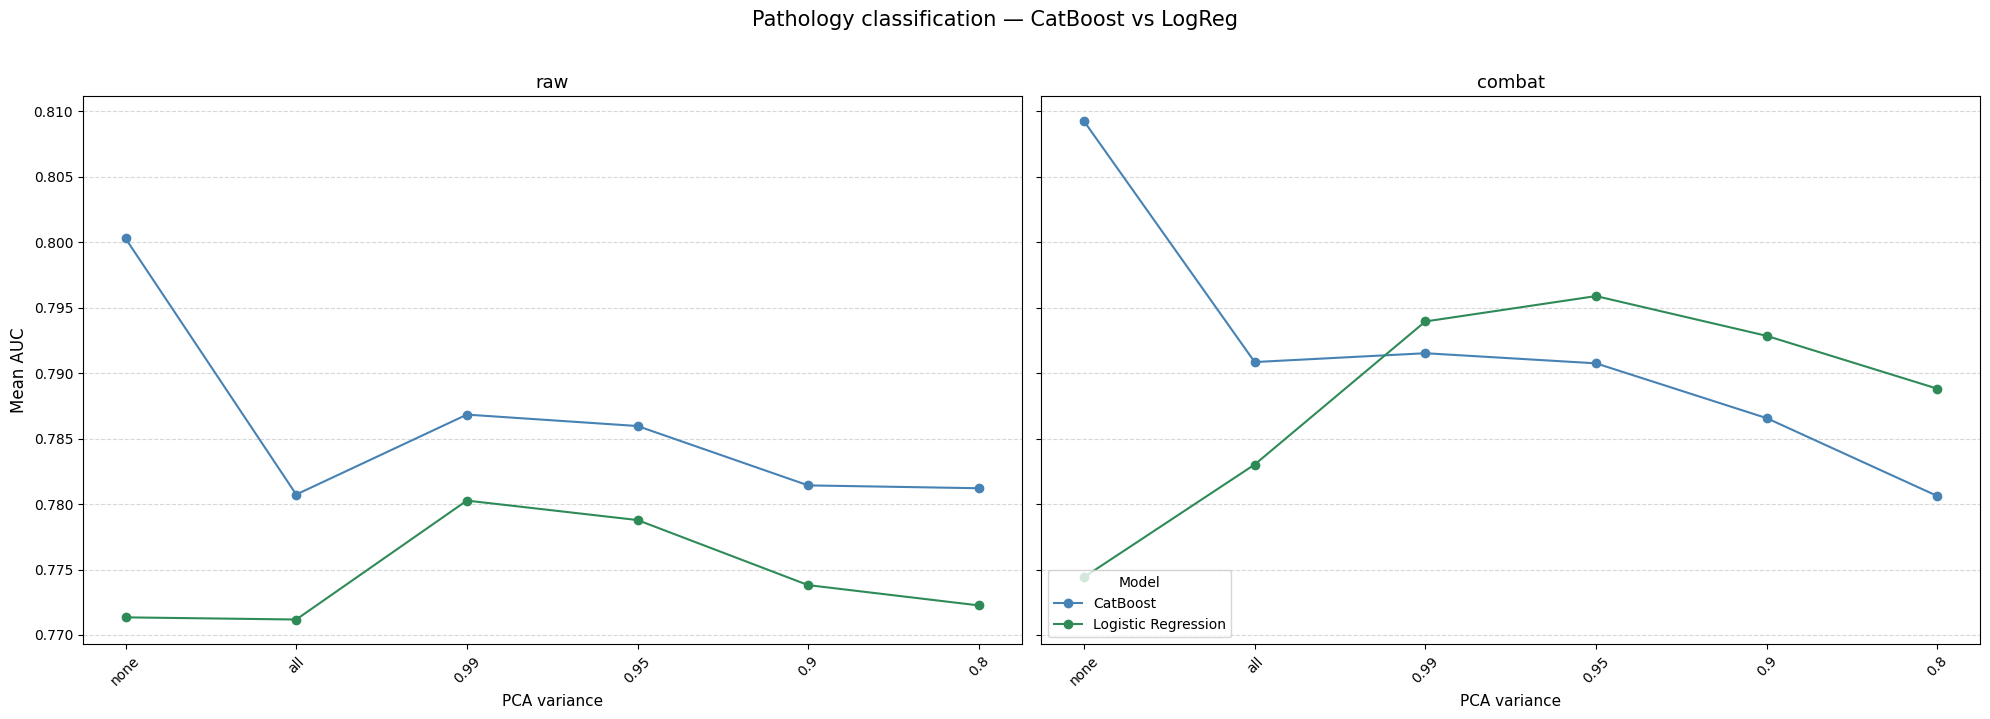

In [64]:
MODEL_COLORS = {'catboost': 'steelblue', 'logreg': 'seagreen'}
MODEL_LABELS = {'catboost': 'CatBoost', 'logreg': 'Logistic Regression'}

agg = multimodel_df.groupby(['method', 'model', 'pca_var'])['auc'].mean().reset_index()

fig, axes = plt.subplots(1, len(METHODS), figsize=(20, 7), sharey=True)

for ax, method in zip(axes, METHODS):
    for model_name in MODELS:
        subset = agg[(agg['method'] == method) & (agg['model'] == model_name)]
        subset = subset.set_index('pca_var').reindex(PCA_VARIANTS)
        ax.plot(PCA_VARIANTS, subset['auc'].values, marker='o',
                color=MODEL_COLORS[model_name], label=MODEL_LABELS[model_name])
        ax.set_title(method, fontsize=13)
        ax.set_xlabel('PCA variance', fontsize=11)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

axes[0].set_ylabel('Mean AUC', fontsize=12)
axes[-1].legend(title='Model', loc='lower left')
fig.suptitle('Pathology classification — CatBoost vs LogReg', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/patho_auc_multimodel_by_method.png", dpi=150, bbox_inches='tight')
plt.show()